Ejercicio 1.

Recorta el punto de interés de la imagenP.jpg tal cual se muestra en la figura, guarda la imagen recortada en tu disco local, y muestra la imagen original y la recortada con axis (imagen a colores)

✅ Carpeta creada: clases/img/imagenes_resultado
✅ Recorte guardado en: clases/img/imagenes_resultado\imagenP_recortada.png


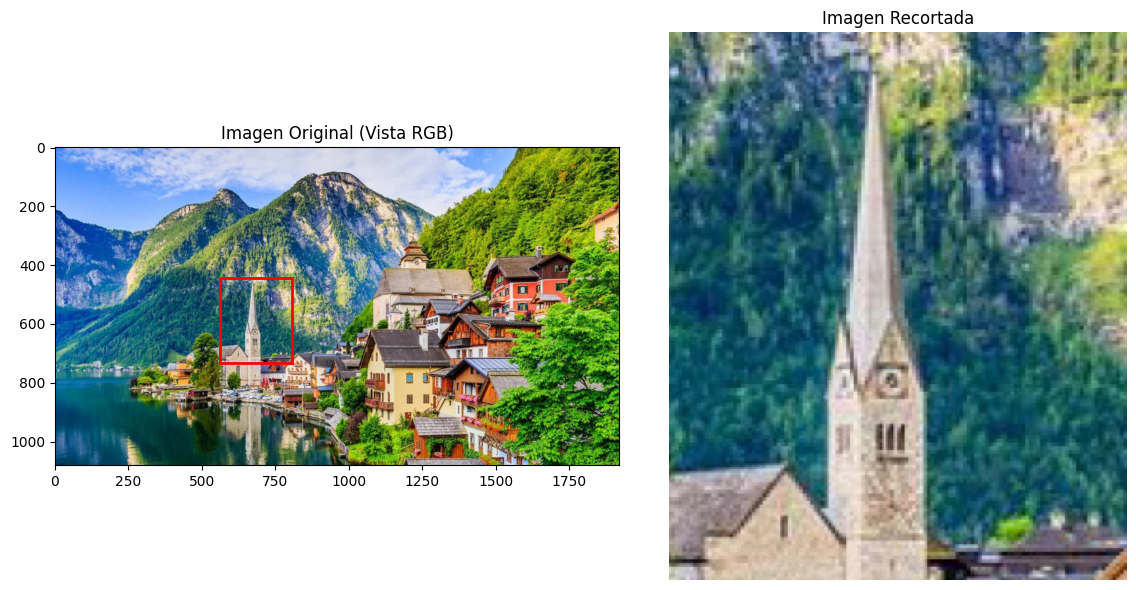

In [1]:
import cv2
import matplotlib.pyplot as plt
import os # <-- CAMBIO 1: Importamos os para gestionar carpetas y rutas

# --- CONFIGURACIÓN DE RUTAS ---
# CAMBIO 2: Definimos la carpeta base de tu proyecto en VS Code
carpeta_base = 'clases/img/'
# CAMBIO 3: Definimos la carpeta donde se guardarán los resultados
carpeta_salida = os.path.join(carpeta_base, 'imagenes_resultado')

# CAMBIO 4: Si la carpeta de salida no existe, la creamos para evitar errores al guardar
if not os.path.exists(carpeta_salida):
    os.makedirs(carpeta_salida)
    print(f"✅ Carpeta creada: {carpeta_salida}")

# CAMBIO 5: Corregimos el nombre del archivo a 'imagenP.jpeg'
nombre_archivo = 'imagenP.jpeg'
ruta_lectura = os.path.join(carpeta_base, nombre_archivo)

imagen_bgr = cv2.imread(ruta_lectura)

if imagen_bgr is None:
    print(f"❌ Error: No se encontró la imagen en {ruta_lectura}")
else:
    # Convertimos a RGB para procesar con Matplotlib
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

    # Coordenadas de recorte (Slicing de Numpy)
    inicio_fila = 442
    fin_fila = 733
    inicio_columna = 562
    fin_columna = 805

    # Aplicamos el recorte: [filas, columnas, canales]
    imagen_recortada = imagen_rgb[inicio_fila:fin_fila, inicio_columna:fin_columna, :]

    # --- GUARDAR EL RESULTADO ---
    # CAMBIO 6: Guardamos usando la nueva ruta de salida
    ruta_guardado = os.path.join(carpeta_salida, 'imagenP_recortada.png')
    plt.imsave(ruta_guardado, imagen_recortada)
    print(f"✅ Recorte guardado en: {ruta_guardado}")

    # --- MOSTRAR RESULTADOS ---
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title('Imagen Original (Vista RGB)')
    plt.imshow(imagen_rgb)
    # Dibujamos un cuadro guía opcional para verificar el área de recorte
    plt.gca().add_patch(plt.Rectangle((inicio_columna, inicio_fila), 
                                      fin_columna-inicio_columna, 
                                      fin_fila-inicio_fila, 
                                      edgecolor='red', facecolor='none', lw=2))
    plt.axis('on') # Dejamos los ejes visibles para ver las coordenadas (píxeles)

    plt.subplot(1, 2, 2)
    plt.title('Imagen Recortada')
    plt.imshow(imagen_recortada)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Ejercicio 2.

Genera un degradado lineal a colores (debe coincidir con los mismos colores).

✅ Degradado guardado en: clases/img/imagenes_resultado\degradado_lineal.png


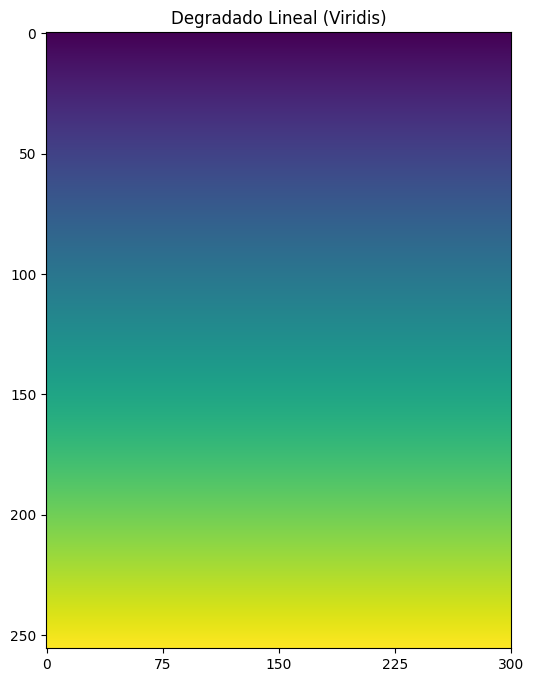

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os # <-- CAMBIO 1: Importamos os para manejar rutas y carpetas

# --- CONFIGURACIÓN DE RUTAS ---
# CAMBIO 2: Definimos la carpeta base de tu proyecto en VS Code
carpeta_base = 'clases/img/'
# CAMBIO 3: Definimos la carpeta de salida para los degradados
carpeta_salida = os.path.join(carpeta_base, 'imagenes_resultado')

# CAMBIO 4: Si la carpeta de salida no existe, la creamos automáticamente
if not os.path.exists(carpeta_salida):
    os.makedirs(carpeta_salida)
    print(f"✅ Carpeta de salida lista: {carpeta_salida}")

# --- GENERACIÓN DE LA IMAGEN ---
valor_minimo = 0
valor_maximo = 1
alto_imagen = 256
ancho_imagen = 300

# Creamos la columna con linspace y la repetimos para crear el degradado
columna = np.linspace(valor_minimo, valor_maximo, alto_imagen)[:, None]
imagen_degradada = np.repeat(columna, ancho_imagen, axis=1)

# --- GUARDAR IMAGEN ---
# CAMBIO 5: Usamos os.path.join para guardar en la ruta correcta dentro de clases/img/
ruta_guardado = os.path.join(carpeta_salida, 'degradado_lineal.png')
plt.imsave(ruta_guardado, imagen_degradada, cmap='viridis')
print(f"✅ Degradado guardado en: {ruta_guardado}")

# --- MOSTRAR IMAGEN ---
plt.figure(figsize=(6, 8))
plt.title('Degradado Lineal (Viridis)')
# El mapa de color 'viridis' es el estándar por defecto de Matplotlib
plt.imshow(imagen_degradada, cmap='viridis', aspect='auto')

# CAMBIO 6: Ajuste de límites para que la visualización sea clara
# Estos valores dependen de qué parte del degradado quieras resaltar
plt.xlim(-0.5, ancho_imagen - 0.5) 
plt.xticks(np.linspace(0, ancho_imagen, 5))
plt.show()

Ejercicio 3.

Genera una imagen semejante a un tablero de ajedrez tomando en cuenta que cada casilla debe medir 100x100 px

✅ Carpeta creada con éxito: clases/img/img_ejercicio_3
✅ Tablero guardado en: clases/img/img_ejercicio_3\tablero_ajedrez.png


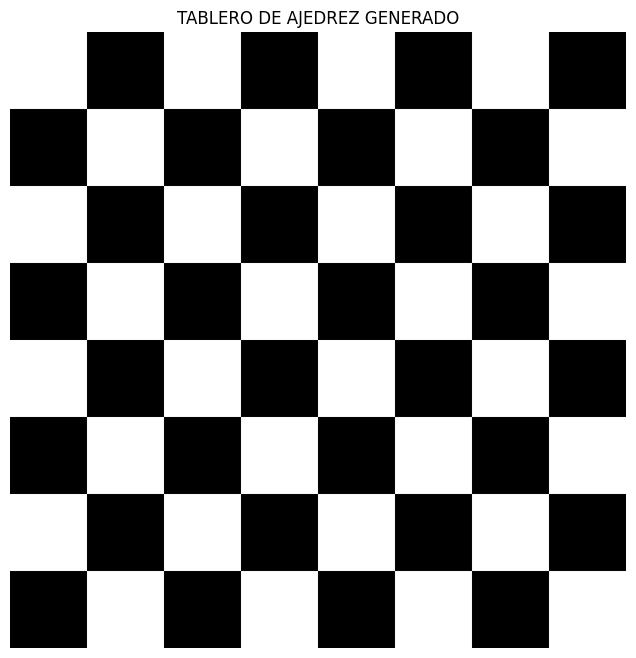

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os # <-- CAMBIO 1: Importamos os para manejar directorios de forma segura

# --- CONFIGURACIÓN DE RUTAS ---
# CAMBIO 2: Ajustamos a la carpeta base de tu proyecto en VS Code
carpeta_base = 'clases/img/'
# CAMBIO 3: Definimos la subcarpeta específica para este ejercicio
carpeta_ejercicio = os.path.join(carpeta_base, 'img_ejercicio_3')

# CAMBIO 4: Si la carpeta no existe, la creamos para que plt.imsave no de error
if not os.path.exists(carpeta_ejercicio):
    os.makedirs(carpeta_ejercicio)
    print(f"✅ Carpeta creada con éxito: {carpeta_ejercicio}")

# --- PARÁMETROS DEL TABLERO ---
tamanio_casilla = 100
numero_casillas = 8
tamanio_imagen = tamanio_casilla * numero_casillas

# Creamos lienzo negro (3 canales para RGB)
imagen_ajedrez = np.zeros((tamanio_imagen, tamanio_imagen, 3), dtype=np.uint8)

# --- ASIGNAR COLORES AL TABLERO ---
for fila in range(numero_casillas):
    for columna in range(numero_casillas):
        # Lógica de color: si la suma de fila + columna es par, es blanca
        if (fila + columna) % 2 == 0:
            color = [255, 255, 255] # Blanco
        else:
            color = [0, 0, 0] # Negro

        # Calcular límites de la casilla
        inicio_fila = fila * tamanio_casilla
        fin_fila = inicio_fila + tamanio_casilla
        inicio_columna = columna * tamanio_casilla
        fin_columna = inicio_columna + tamanio_casilla

        # Asignar color mediante slicing de Numpy
        imagen_ajedrez[inicio_fila:fin_fila, inicio_columna:fin_columna] = color

# --- GUARDAR IMAGEN ---
# CAMBIO 5: Usamos la ruta completa corregida
ruta_guardado = os.path.join(carpeta_ejercicio, "tablero_ajedrez.png")
plt.imsave(ruta_guardado, imagen_ajedrez)
print(f"✅ Tablero guardado en: {ruta_guardado}")

# --- MOSTRAR IMAGEN ---
plt.figure(figsize=(8, 8))
plt.imshow(imagen_ajedrez)
plt.title("TABLERO DE AJEDREZ GENERADO")
plt.axis('off') # Opcional: oculta los ejes para que se vea más limpio
plt.show()

Ejercicio 4.

Tomando en cuenta el resultado del ejercicio 2 aplica posterizacion y solarizacion, de la misma manera aplica todas las paletas de falso color cada resultado debe guardarse.

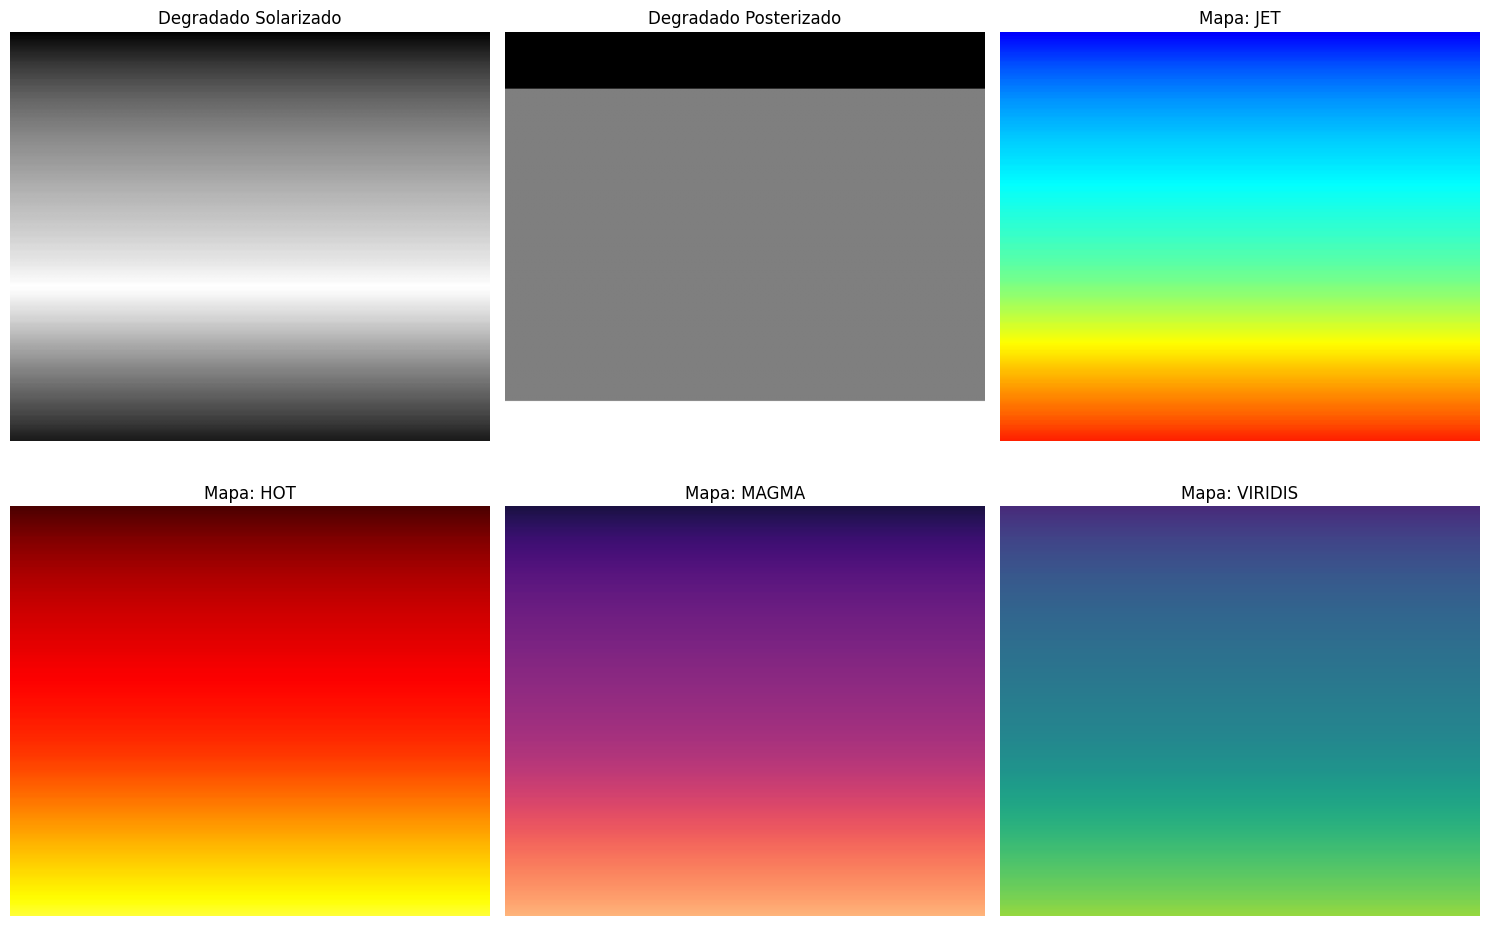

✅ Proceso completado. Resultados en: clases/img/img_ejercicio_4


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- CONFIGURACIÓN DE RUTAS ---
# CAMBIO 1: La carpeta donde realmente está tu imagen según la captura
carpeta_base = 'clases/img/'

# CAMBIO 2: Definimos la carpeta de salida (donde quieres que se guarden los nuevos efectos)
carpeta_salida = os.path.join(carpeta_base, 'img_ejercicio_4')

# Creamos la carpeta de salida si no existe
if not os.path.exists(carpeta_salida):
    os.makedirs(carpeta_salida)

# CAMBIO 3: Ruta de lectura corregida (buscando directamente en la carpeta img)
nombre_archivo = 'degradado_lineal.png'
ruta_lectura = os.path.join(carpeta_base, nombre_archivo)

imagen_bgr = cv2.imread(ruta_lectura)

if imagen_bgr is None:
    # Si falla, imprimimos la ruta absoluta para ver dónde está buscando exactamente Python
    print(f"❌ Error: No se encontró en {os.path.abspath(ruta_lectura)}")
else:
    # Convertimos a gris para los procesos
    imagen_gray = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)

    def solarizar(imagen, umbral):
        img_sol = np.where(imagen < umbral, imagen, 255 - imagen)
        return img_sol.astype(np.uint8)

    def posterizar(imagen, niveles):
        factor_escala = 255 / (niveles - 1)
        img_pos = np.round(imagen / factor_escala) * factor_escala
        return np.clip(img_pos, 0, 255).astype(np.uint8)

    # --- PROCESAMIENTO ---
    umbral = 128
    imagen_solarizada = solarizar(imagen_gray, umbral)
    
    niveles = 3
    imagen_posterizada = posterizar(imagen_gray, niveles)

    # --- GUARDAR RESULTADOS ---
    plt.imsave(os.path.join(carpeta_salida, 'degradado_solarizado.png'), imagen_solarizada, cmap='gray')
    plt.imsave(os.path.join(carpeta_salida, 'degradado_posterizado.png'), imagen_posterizada, cmap='gray')

    # --- MAPAS DE COLOR ---
    colormaps = [cv2.COLORMAP_JET, cv2.COLORMAP_HOT, cv2.COLORMAP_MAGMA, cv2.COLORMAP_VIRIDIS]
    nombres = ["JET", "HOT", "MAGMA", "VIRIDIS"]

    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 3, 1)
    plt.title('Degradado Solarizado')
    plt.imshow(imagen_solarizada, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.title('Degradado Posterizado')
    plt.imshow(imagen_posterizada, cmap='gray')
    plt.axis('off')

    for i in range(len(colormaps)):
        img_c = cv2.applyColorMap(imagen_gray, colormaps[i])
        img_rgb = cv2.cvtColor(img_c, cv2.COLOR_BGR2RGB)
        
        plt.subplot(2, 3, i + 3)
        plt.title(f'Mapa: {nombres[i]}')
        plt.imshow(img_rgb)
        plt.axis('off')
        
        # Guardar cada uno en la carpeta de salida
        plt.imsave(os.path.join(carpeta_salida, f'degradado_{nombres[i]}.png'), img_rgb)

    plt.tight_layout()
    plt.show()
    print(f"✅ Proceso completado. Resultados en: {carpeta_salida}")

Ejercicio 5.

Tomando en cuenta la imagen1.jpg aplica un degradado lineal en ella.

✅ Imagen guardada en: clases/img/img_ejercicio_5\imagen_degradado_lineal.png


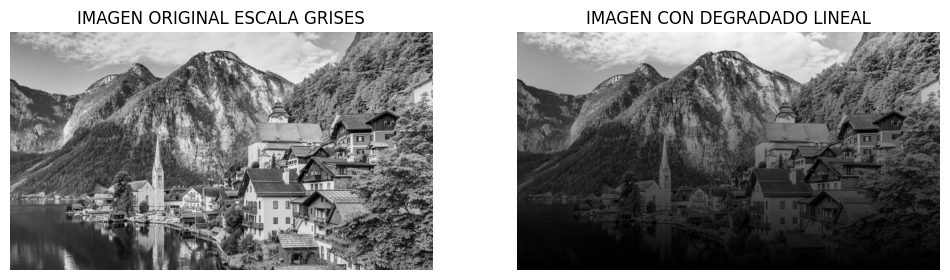

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os # <-- CAMBIO 1: Importamos os para manejar rutas

# --- CONFIGURACIÓN DE RUTAS ---
# CAMBIO 2: Ajustamos a la carpeta de tu proyecto en Univalle
carpeta_base = 'clases/img/'
carpeta_salida = os.path.join(carpeta_base, 'img_ejercicio_5')

# CAMBIO 3: Creamos la carpeta de salida si no existe
if not os.path.exists(carpeta_salida):
    os.makedirs(carpeta_salida)

# CAMBIO 4: Ruta de lectura corregida
ruta_lectura = os.path.join(carpeta_base, 'imagenP.jpeg')
imagen_escala_grises = cv2.imread(ruta_lectura, 0) # El 0 carga directamente en gris

# Verificación de seguridad
if imagen_escala_grises is None:
    print(f"❌ Error: No se encontró la imagen en {os.path.abspath(ruta_lectura)}")
else:
    alto, ancho = imagen_escala_grises.shape
    valor_inicial = 1 # maxima luminosidad
    valor_final = 0 # minima luminosidad

    # Generamos el vector de degradado
    vector_degradado = np.linspace(valor_inicial, valor_final, alto)
    degradado = vector_degradado.reshape(alto, 1)

    # Multiplicamos la imagen por el degradado
    # CAMBIO 5: Aseguramos que la operación sea válida antes del cast a uint8
    imagen_degradado_lineal = (imagen_escala_grises * degradado).astype(np.uint8)

    # --- GUARDAR IMAGEN ---
    # CAMBIO 6: Guardamos en la ruta correcta
    ruta_guardado = os.path.join(carpeta_salida, "imagen_degradado_lineal.png")
    plt.imsave(ruta_guardado, imagen_degradado_lineal, cmap='gray')
    print(f"✅ Imagen guardada en: {ruta_guardado}")

    # --- MOSTRAR IMAGENES ---
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(imagen_escala_grises, cmap='gray')
    plt.title("IMAGEN ORIGINAL ESCALA GRISES")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(imagen_degradado_lineal, cmap='gray')
    plt.title("IMAGEN CON DEGRADADO LINEAL")
    plt.axis('off')

    plt.show()

Ejercicio 6.

Elabora una imagen original, usando unicamente cuadrados , no tiene que parecerse a los ejecicios realizados en clase , posterior debe aplicarse el filtro bayer en todas sus convinaciones mostrar y guardar todos los resultados con sus titulos correspondientes.

PARTE 1 CREAR LA IMAGEN ORIGINAL USANDO UNICAMENTE CUADRADOS

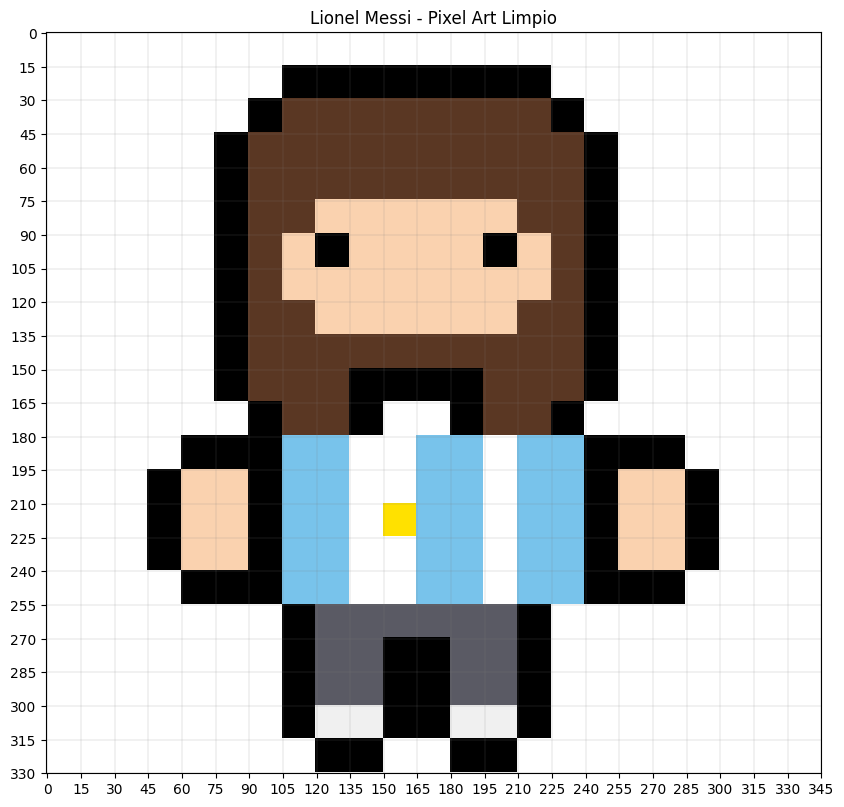

✅ ¡Messi limpio generado! Guardado en: clases/img/img_ejercicio_messi\messi_pixel_art_limpio.png


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- CONFIGURACIÓN DE RUTAS ---
# Mantenemos las rutas de tu proyecto en Univalle
carpeta_base = 'clases/img/'
carpeta_ejercicio = os.path.join(carpeta_base, 'img_ejercicio_messi')

if not os.path.exists(carpeta_ejercicio):
    os.makedirs(carpeta_ejercicio)

# --- PARÁMETROS DEL DISEÑO ---
tamano_casilla = 15  # Cada "píxel" será un cuadrado de 15x15 píxeles reales

# DISEÑO DE MESSI (Mapa de caracteres)
# Mismo diseño lógico, forma exactamente igual a la referencia
diseno = [
    ".......................",
    ".......********........",
    "......*CCCCCCCC*.......",
    ".....*CCCCCCCCCC*......",
    ".....*CCCCCCCCCC*......",
    ".....*CCPPPPPPCC*......",
    ".....*CP*PPPP*PC*......",
    ".....*CPPPPPPPPC*......",
    ".....*CCPPPPPPCC*......",
    ".....*CCCCCCCCCC*......",
    ".....*CCC****CCC*......",
    "......*CC*BB*CC*.......",
    "....***AABBAABAA***....",
    "...*PP*AABBAABAA*PP*...",
    "...*PP*AABDAABAA*PP*...",
    "...*PP*AABBAABAA*PP*...",
    "....***AABBAABAA***....",
    ".......*GGGGGG*........",
    ".......*GG**GG*........",
    ".......*GG**GG*........",
    ".......*ZZ**ZZ*........",
    "........**..**........."
]

# MAPA DE COLORES (RGB)
# Ajustados para que coincidan perfectamente con la imagen de referencia limpia
mapa_colores = {
    ".": [255, 255, 255], # Blanco puro fondo
    "*": [0, 0, 0],       # Negro puro (bordes y ojos)
    "C": [90, 55, 35],    # Café (Cabello y barba)
    "P": [250, 210, 175], # Piel
    "B": [255, 255, 255], # Blanco camiseta
    "A": [120, 195, 235], # Celeste Argentina
    "D": [255, 225, 0],   # Dorado escudo
    "G": [90, 90, 100],   # Gris oscuro pantalón
    "Z": [240, 240, 240]  # Blanco zapatos
}

# Dimensiones
numero_filas = len(diseno)
numero_columnas = len(diseno[0])
alto_imagen = numero_filas * tamano_casilla
ancho_imagen = numero_columnas * tamano_casilla

# Crear lienzo
imagen = np.zeros((alto_imagen, ancho_imagen, 3), dtype=np.uint8)

# --- CONSTRUCCIÓN DE LA IMAGEN ---
# (Mismo proceso de llenado de bloques)
for fila in range(numero_filas):
    for columna in range(numero_columnas):
        simbolo = diseno[fila][columna]
        color = mapa_colores[simbolo]

        inicio_fila = fila * tamano_casilla
        fin_fila = inicio_fila + tamano_casilla
        inicio_columna = columna * tamano_casilla
        fin_columna = inicio_columna + tamano_casilla

        imagen[inicio_fila:fin_fila, inicio_columna:fin_columna] = color

# --- GUARDADO Y VISUALIZACIÓN MEJORADA ---
ruta_guardado = os.path.join(carpeta_ejercicio, "messi_pixel_art_limpio.png")
# plt.imsave guarda la matriz uint8 directamente sin suavizado
plt.imsave(ruta_guardado, imagen)

# Ajuste del tamaño de visualización para que no se amontone
plt.figure(figsize=(10, 10))

# --- CAMBIO CRUCIAL AQUÍ ---
# interpolation='nearest' asegura que los bordes de los bloques sean nítidos
plt.imshow(imagen, interpolation='nearest')

plt.title("Lionel Messi - Pixel Art Limpio")
plt.axis("on") # Dejamos los ejes para referencia de la cuadrícula

# Ajustamos las marcas para que coincidan con las casillas lógicas
plt.xticks(np.arange(0, ancho_imagen + 1, tamano_casilla))
plt.yticks(np.arange(0, alto_imagen + 1, tamano_casilla))

# Ajuste de rejilla para que sea muy suave pero visible, como en el cuaderno
plt.grid(color='gray', linestyle='-', linewidth=0.3, alpha=0.5)

plt.show()

print(f"✅ ¡Messi limpio generado! Guardado en: {ruta_guardado}")

PARTE 2 APLICAR FILTRO BAYER EN TODAS SUS 4 CONVINACIONES, GUARDARLAS Y MOSTRARLAS

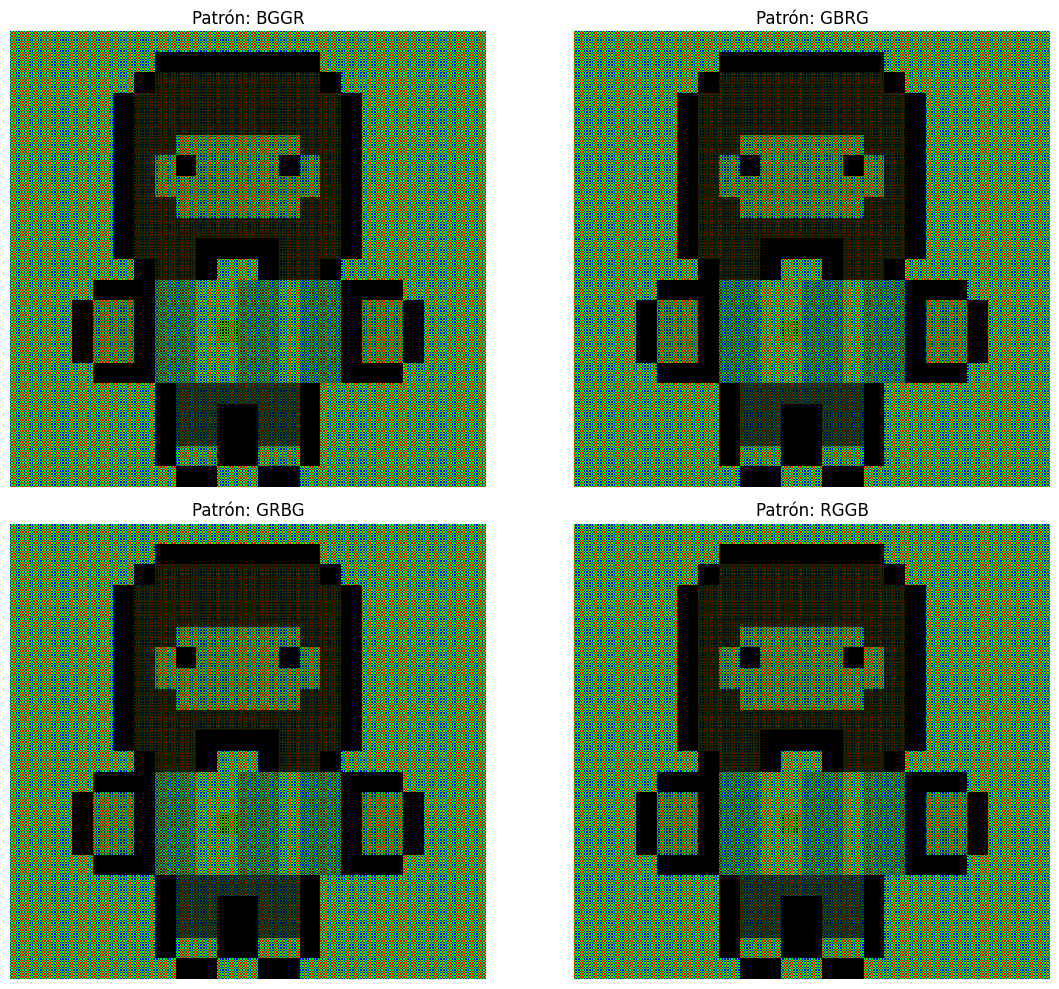

✅ ¡Hecho! Resultados en: clases/img/img_ejercicio_bayer


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURACIÓN DE RUTAS ---
carpeta_base = 'clases/img/'
carpeta_messi = os.path.join(carpeta_base, 'img_ejercicio_messi')
nombre_archivo = 'messi_pixel_art_limpio.png'
ruta_entrada = os.path.join(carpeta_messi, nombre_archivo)

carpeta_salida = os.path.join(carpeta_base, 'img_ejercicio_bayer')

if not os.path.exists(carpeta_salida):
    os.makedirs(carpeta_salida)

# --- 2. FUNCIONES DE PROCESAMIENTO ---
def separar_canales(imagen):
    return imagen[:, :, 0], imagen[:, :, 1], imagen[:, :, 2]

def reconstruir_rgb(rojo, verde, azul):
    return np.stack((rojo, verde, azul), axis=2)

def aplicar_patron_bayer(rojo, verde, azul, patron):
    alto, ancho = rojo.shape
    mosaico = np.zeros((alto, ancho), dtype=np.uint8)

    # Simulación de captura de sensor
    if patron == "BGGR":
        mosaico[0::2, 0::2] = azul[0::2, 0::2]
        mosaico[0::2, 1::2] = verde[0::2, 1::2]
        mosaico[1::2, 0::2] = verde[1::2, 0::2]
        mosaico[1::2, 1::2] = rojo[1::2, 1::2]
    elif patron == "GBRG":
        mosaico[0::2, 0::2] = verde[0::2, 0::2]
        mosaico[0::2, 1::2] = azul[0::2, 1::2]
        mosaico[1::2, 0::2] = rojo[1::2, 0::2]
        mosaico[1::2, 1::2] = verde[1::2, 1::2]
    elif patron == "GRBG":
        mosaico[0::2, 0::2] = verde[0::2, 0::2]
        mosaico[0::2, 1::2] = rojo[0::2, 1::2]
        mosaico[1::2, 0::2] = azul[1::2, 0::2]
        mosaico[1::2, 1::2] = verde[1::2, 1::2]
    elif patron == "RGGB":
        mosaico[0::2, 0::2] = rojo[0::2, 0::2]
        mosaico[0::2, 1::2] = verde[0::2, 1::2]
        mosaico[1::2, 0::2] = verde[1::2, 0::2]
        mosaico[1::2, 1::2] = azul[1::2, 1::2]

    # Reconstrucción de canales
    r_res = np.zeros_like(rojo); g_res = np.zeros_like(verde); b_res = np.zeros_like(azul)

    if patron == "BGGR":
        b_res[0::2, 0::2] = mosaico[0::2, 0::2]; g_res[0::2, 1::2] = mosaico[0::2, 1::2]
        g_res[1::2, 0::2] = mosaico[1::2, 0::2]; r_res[1::2, 1::2] = mosaico[1::2, 1::2]
    elif patron == "GBRG":
        g_res[0::2, 0::2] = mosaico[0::2, 0::2]; b_res[0::2, 1::2] = mosaico[0::2, 1::2]
        r_res[1::2, 0::2] = mosaico[1::2, 0::2]; g_res[1::2, 1::2] = mosaico[1::2, 1::2]
    elif patron == "GRBG":
        g_res[0::2, 0::2] = mosaico[0::2, 0::2]; r_res[0::2, 1::2] = mosaico[0::2, 1::2]
        b_res[1::2, 0::2] = mosaico[1::2, 0::2]; g_res[1::2, 1::2] = mosaico[1::2, 1::2]
    elif patron == "RGGB":
        r_res[0::2, 0::2] = mosaico[0::2, 0::2]; g_res[0::2, 1::2] = mosaico[0::2, 1::2]
        g_res[1::2, 0::2] = mosaico[1::2, 0::2]; b_res[1::2, 1::2] = mosaico[1::2, 1::2]

    return reconstruir_rgb(r_res, g_res, b_res)

# --- 3. EJECUCIÓN ---
imagen_bgr = cv2.imread(ruta_entrada)

if imagen_bgr is None:
    print(f"❌ Error: No se encontró en {ruta_entrada}")
else:
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    rojo, verde, azul = separar_canales(imagen_rgb)
    
    patrones = ["BGGR", "GBRG", "GRBG", "RGGB"]
    plt.figure(figsize=(12, 10))
    
    for i, patron in enumerate(patrones):
        reconstruida = aplicar_patron_bayer(rojo, verde, azul, patron)
        
        # --- CORRECCIÓN CLAVE ---
        # imsave NO lleva interpolation. Se guarda tal cual es la matriz.
        ruta_save = os.path.join(carpeta_salida, f"messi_bayer_{patron}.png")
        plt.imsave(ruta_save, reconstruida)
        
        plt.subplot(2, 2, i + 1)
        # imshow SÍ lleva interpolation para que se vea bien en pantalla.
        plt.imshow(reconstruida, interpolation='nearest')
        plt.title(f"Patrón: {patron}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"✅ ¡Hecho! Resultados en: {carpeta_salida}")